# Customer Segmentation — Data Preparation & Preprocessing

**Project:** Customer Segmentation (Topic 8)  
**Goal:** Segment customers into distinct groups based on demographic, behavioural, and transactional data to allow businesses to tailor marketing strategies.

---





---
## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
plt.style.use('seaborn-v0_8-whitegrid')

print('All libraries loaded successfully!')

All libraries loaded successfully!


---
## 2. Load Dataset

In [2]:
df = pd.read_csv('Customer_segmentation_dataset.csv')

print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print('\nFirst 5 rows:')
df.head()

Dataset shape: 2,627 rows × 10 columns

First 5 rows:


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,458989,Female,Yes,36,Yes,Engineer,0.000,Low,1.000,Cat_6
1,458994,Male,Yes,37,Yes,Healthcare,8.000,Average,4.000,Cat_6
2,458996,Female,Yes,69,No,NaN,0.000,Low,1.000,Cat_6
3,459000,Male,Yes,59,No,Executive,11.000,High,2.000,Cat_6
4,459001,Female,No,19,No,Marketing,NaN,Low,4.000,Cat_6


---
## 3. Data Exploration (EDA)

In [3]:
print('Column data types:')
print(df.dtypes)
print()
print('Memory usage:')
df.info()

Column data types:
ID                   int64
Gender              object
Ever_Married        object
Age                  int64
Graduated           object
Profession          object
Work_Experience    float64
Spending_Score      object
Family_Size        float64
Var_1               object
dtype: object

Memory usage:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2627 entries, 0 to 2626
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               2627 non-null   int64  
 1   Gender           2627 non-null   object 
 2   Ever_Married     2577 non-null   object 
 3   Age              2627 non-null   int64  
 4   Graduated        2603 non-null   object 
 5   Profession       2589 non-null   object 
 6   Work_Experience  2358 non-null   float64
 7   Spending_Score   2627 non-null   object 
 8   Family_Size      2514 non-null   float64
 9   Var_1            2595 non-null   object 
dtypes: float64(2), int

In [4]:
print('Numeric summary:')
df.describe()

Numeric summary:


,ID,Age,Work_Experience,Family_Size
count,2627.000,2627.000,2358.000,2514.000
mean,463433.919,43.650,2.553,2.825
std,2618.246,16.967,3.341,1.552
min,458989.000,18.000,0.000,1.000
25%,461162.500,30.000,0.000,2.000
50%,463379.000,41.000,1.000,2.000
75%,465696.000,53.000,4.000,4.000
max,467968.000,89.000,14.000,9.000


In [5]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns: {cat_cols}\n')
for col in cat_cols:
    print(f'--- {col} ---')
    print(df[col].value_counts(dropna=False))
    print()

Categorical columns: ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1']

--- Gender ---
Gender
Male      1424
Female    1203
Name: count, dtype: int64

--- Ever_Married ---
Ever_Married
Yes    1520
No     1057
NaN      50
Name: count, dtype: int64

--- Graduated ---
Graduated
Yes    1602
No     1001
NaN      24
Name: count, dtype: int64

--- Profession ---
Profession
Artist           802
Healthcare       418
Entertainment    301
Doctor           242
Engineer         236
Lawyer           221
Executive        176
Marketing        111
Homemaker         82
NaN               38
Name: count, dtype: int64

--- Spending_Score ---
Spending_Score
Low        1616
Average     625
High        386
Name: count, dtype: int64

--- Var_1 ---
Var_1
Cat_6    1672
Cat_4     386
Cat_3     267
Cat_2     141
Cat_7      66
Cat_1      34
NaN        32
Cat_5      29
Name: count, dtype: int64



Columns with missing values:


,Missing Count,Missing %
Work_Experience,269,10.240
Family_Size,113,4.300
Ever_Married,50,1.900
Profession,38,1.450
Var_1,32,1.220
Graduated,24,0.910


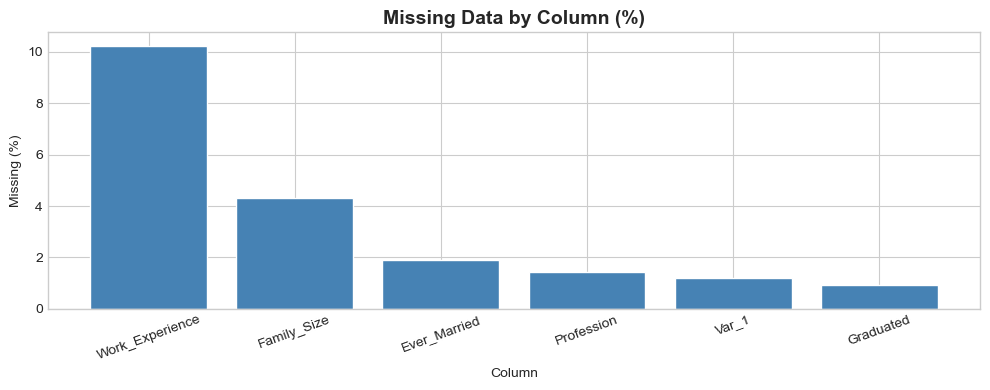

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print('Columns with missing values:')
display(missing_df)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(missing_df.index, missing_df['Missing %'], color='steelblue', edgecolor='white')
ax.set_title('Missing Data by Column (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Column')
ax.set_ylabel('Missing (%)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

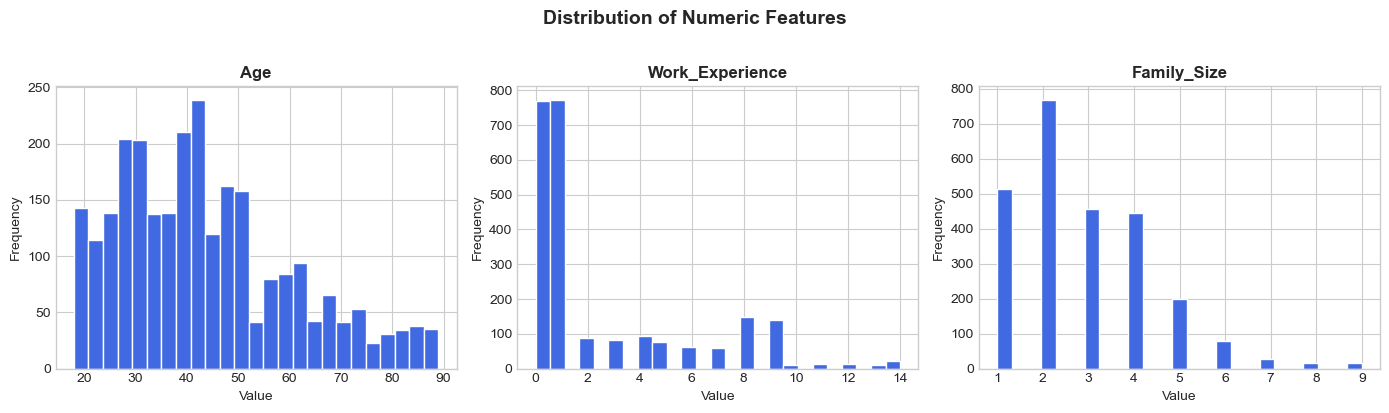

In [7]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'ID']

fig, axes = plt.subplots(1, len(num_cols), figsize=(14, 4))
for ax, col in zip(axes, num_cols):
    df[col].dropna().hist(ax=ax, bins=25, color='royalblue', edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
plt.suptitle('Distribution of Numeric Features', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

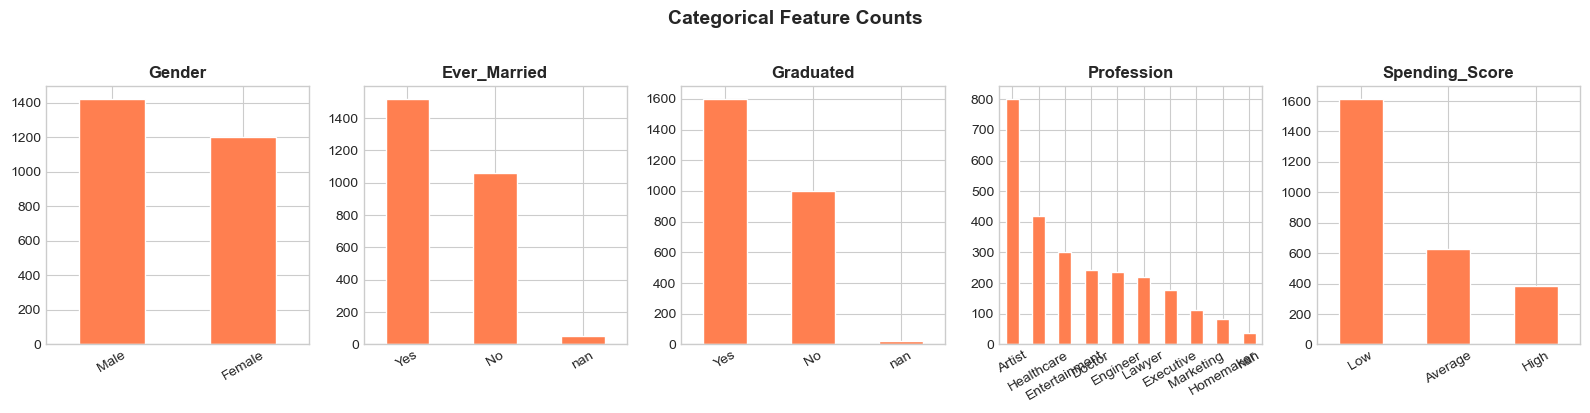

In [8]:
plot_cats = [c for c in cat_cols if c != 'Var_1']
fig, axes = plt.subplots(1, len(plot_cats), figsize=(16, 4))
for ax, col in zip(axes, plot_cats):
    vc = df[col].value_counts(dropna=False)
    vc.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Categorical Feature Counts', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Data Preparation

Steps covered:
- Drop the `ID` column (non-predictive identifier)
- Remove duplicate rows
- Handle missing values

In [9]:
df_clean = df.drop(columns=['ID'])
print(f'Shape after dropping ID: {df_clean.shape}')

Shape after dropping ID: (2627, 9)


In [10]:
n_dup = df_clean.duplicated().sum()
print(f'Duplicate rows found: {n_dup}')
df_clean = df_clean.drop_duplicates()
print(f'Shape after removing duplicates: {df_clean.shape}')

Duplicate rows found: 75
Shape after removing duplicates: (2552, 9)


In [11]:
cat_fill_cols = ['Ever_Married', 'Graduated', 'Profession', 'Var_1']
num_fill_cols = ['Work_Experience', 'Family_Size']

for col in cat_fill_cols:
    mode_val = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mode_val)
    print(f'  [{col}] filled NaN with mode → "{mode_val}"')

for col in num_fill_cols:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f'  [{col}] filled NaN with median → {median_val}')

print(f'\nMissing values remaining: {df_clean.isnull().sum().sum()}')

  [Ever_Married] filled NaN with mode → "Yes"
  [Graduated] filled NaN with mode → "Yes"
  [Profession] filled NaN with mode → "Artist"
  [Var_1] filled NaN with mode → "Cat_6"
  [Work_Experience] filled NaN with median → 1.0
  [Family_Size] filled NaN with median → 2.0

Missing values remaining: 0


---
## 5. Data Preprocessing — Encoding Categorical Variables



In [12]:
df_encoded = df_clean.copy()

binary_map = {
    'Gender':       {'Male': 0, 'Female': 1},
    'Ever_Married': {'No': 0, 'Yes': 1},
    'Graduated':    {'No': 0, 'Yes': 1},
}
for col, mapping in binary_map.items():
    df_encoded[col] = df_encoded[col].map(mapping)
    print(f'  [{col}] encoded: {mapping}')

print()

  [Gender] encoded: {'Male': 0, 'Female': 1}
  [Ever_Married] encoded: {'No': 0, 'Yes': 1}
  [Graduated] encoded: {'No': 0, 'Yes': 1}



In [13]:
spending_map = {'Low': 0, 'Average': 1, 'High': 2}
df_encoded['Spending_Score'] = df_encoded['Spending_Score'].map(spending_map)
print(f'Spending_Score ordinal map: {spending_map}')
print(df_encoded['Spending_Score'].value_counts().sort_index())

Spending_Score ordinal map: {'Low': 0, 'Average': 1, 'High': 2}
Spending_Score
0    1569
1     614
2     369
Name: count, dtype: int64


In [14]:
df_encoded = pd.get_dummies(df_encoded, columns=['Profession', 'Var_1'], drop_first=True)
print(f'Shape after one-hot encoding: {df_encoded.shape}')
print(f'\nColumns now: {list(df_encoded.columns)}')

Shape after one-hot encoding: (2552, 21)

Columns now: ['Gender', 'Ever_Married', 'Age', 'Graduated', 'Work_Experience', 'Spending_Score', 'Family_Size', 'Profession_Doctor', 'Profession_Engineer', 'Profession_Entertainment', 'Profession_Executive', 'Profession_Healthcare', 'Profession_Homemaker', 'Profession_Lawyer', 'Profession_Marketing', 'Var_1_Cat_2', 'Var_1_Cat_3', 'Var_1_Cat_4', 'Var_1_Cat_5', 'Var_1_Cat_6', 'Var_1_Cat_7']


In [15]:
obj_remaining = df_encoded.select_dtypes(include='object').columns.tolist()
bool_cols     = df_encoded.select_dtypes(include='bool').columns.tolist()

df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print(f'Object columns remaining: {obj_remaining}')
print(f'Boolean columns converted to int: {bool_cols}')
df_encoded.head(3)

Object columns remaining: []
Boolean columns converted to int: ['Profession_Doctor', 'Profession_Engineer', 'Profession_Entertainment', 'Profession_Executive', 'Profession_Healthcare', 'Profession_Homemaker', 'Profession_Lawyer', 'Profession_Marketing', 'Var_1_Cat_2', 'Var_1_Cat_3', 'Var_1_Cat_4', 'Var_1_Cat_5', 'Var_1_Cat_6', 'Var_1_Cat_7']


,Gender,Ever_Married,Age,Graduated,Work_Experience,Spending_Score,Family_Size,Profession_Doctor,Profession_Engineer,Profession_Entertainment,Profession_Executive,Profession_Healthcare,Profession_Homemaker,Profession_Lawyer,Profession_Marketing,Var_1_Cat_2,Var_1_Cat_3,Var_1_Cat_4,Var_1_Cat_5,Var_1_Cat_6,Var_1_Cat_7
0,1,1,36,1,0.000,0,1.000,0,1,0,0,0,0,0,0,0,0,0,0,1,0
1,0,1,37,1,8.000,1,4.000,0,0,0,0,1,0,0,0,0,0,0,0,1,0
2,1,1,69,0,0.000,0,1.000,0,0,0,0,0,0,0,0,0,0,0,0,1,0


---
## 6. Outlier Detection & Removal

Using the **IQR (Interquartile Range)** method on continuous numeric features.  


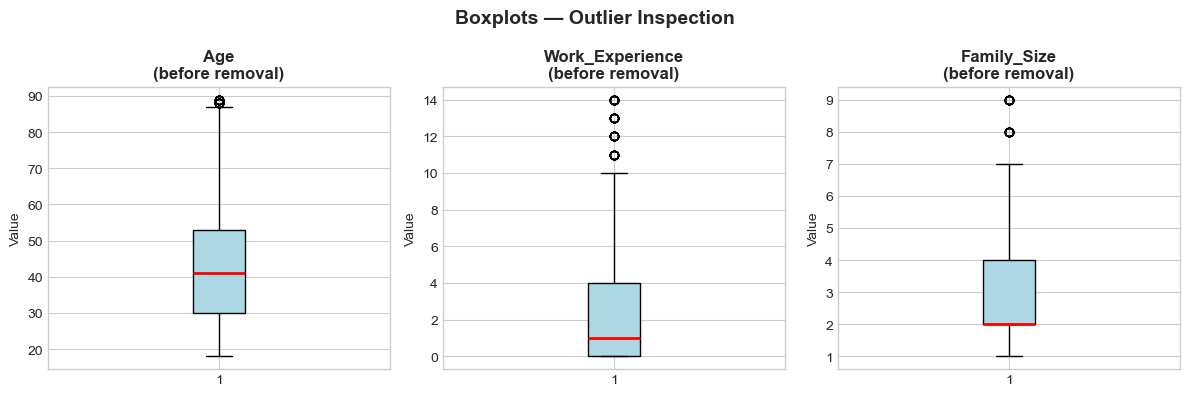

In [16]:
outlier_cols = ['Age', 'Work_Experience', 'Family_Size']

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(12, 4))
for ax, col in zip(axes, outlier_cols):
    ax.boxplot(df_encoded[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='lightblue'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(f'{col}\n(before removal)', fontweight='bold')
    ax.set_ylabel('Value')
plt.suptitle('Boxplots — Outlier Inspection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
df_no_outliers = df_encoded.copy()
rows_before = len(df_no_outliers)

for col in outlier_cols:
    Q1  = df_no_outliers[col].quantile(0.25)
    Q3  = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_no_outliers[col] < lower) | (df_no_outliers[col] > upper)).sum()
    df_no_outliers = df_no_outliers[
        (df_no_outliers[col] >= lower) & (df_no_outliers[col] <= upper)
    ]
    print(f'  [{col}] bounds: [{lower:.2f}, {upper:.2f}] | rows removed: {n_out}')

rows_after = len(df_no_outliers)
print(f'\nRows before: {rows_before:,} → after: {rows_after:,} (removed {rows_before - rows_after})')

  [Age] bounds: [-4.50, 87.50] | rows removed: 19
  [Work_Experience] bounds: [-6.00, 10.00] | rows removed: 58
  [Family_Size] bounds: [-1.00, 7.00] | rows removed: 30

Rows before: 2,552 → after: 2,445 (removed 107)


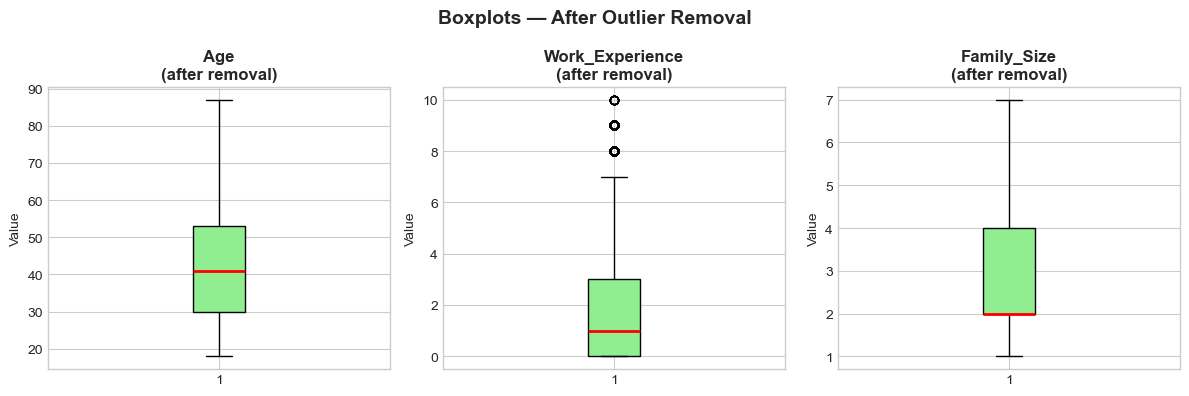

In [18]:
fig, axes = plt.subplots(1, len(outlier_cols), figsize=(12, 4))
for ax, col in zip(axes, outlier_cols):
    ax.boxplot(df_no_outliers[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='lightgreen'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(f'{col}\n(after removal)', fontweight='bold')
    ax.set_ylabel('Value')
plt.suptitle('Boxplots — After Outlier Removal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Feature Engineering

Creating new informative features derived from existing columns to improve clustering quality:


In [19]:
df_fe = df_no_outliers.copy()

bins   = [0, 25, 35, 50, 65, 100]
labels = [0, 1, 2, 3, 4]
df_fe['Age_Group'] = pd.cut(df_fe['Age'], bins=bins, labels=labels).astype(int)
print('Age_Group distribution:')
age_label_map = {0:'Young(≤25)', 1:'YoungAdult(26-35)', 2:'MiddleAged(36-50)',
                 3:'Senior(51-65)', 4:'Elderly(65+)'}
print(df_fe['Age_Group'].map(age_label_map).value_counts())
print()

Age_Group distribution:
Age_Group
MiddleAged(36-50)    869
YoungAdult(26-35)    573
Senior(51-65)        414
Elderly(65+)         301
Young(≤25)           288
Name: count, dtype: int64



In [20]:
df_fe['Experience_per_Age'] = (df_fe['Work_Experience'] / df_fe['Age']).round(4)
print('Experience_per_Age — sample stats:')
print(df_fe['Experience_per_Age'].describe())
print()

Experience_per_Age — sample stats:
count   2445.000
mean       0.061
std        0.088
min        0.000
25%        0.000
50%        0.024
75%        0.073
max        0.474
Name: Experience_per_Age, dtype: float64



In [21]:
df_fe['Is_Senior'] = (df_fe['Age'] >= 60).astype(int)
print(f'Is_Senior counts:\n{df_fe["Is_Senior"].value_counts()}')
print()

Is_Senior counts:
Is_Senior
0    2001
1     444
Name: count, dtype: int64



In [22]:
df_fe['Affluence_Score'] = df_fe['Spending_Score'] + df_fe['Graduated']
print('Affluence_Score distribution:')
print(df_fe['Affluence_Score'].value_counts().sort_index())
print()

Affluence_Score distribution:
Affluence_Score
0     630
1    1021
2     569
3     225
Name: count, dtype: int64



In [23]:
df_fe['Dependents_Flag'] = (df_fe['Family_Size'] > 3).astype(int)
print(f'Dependents_Flag counts:\n{df_fe["Dependents_Flag"].value_counts()}')
print()

print(f'Total features after engineering: {df_fe.shape[1]}')
print(f'Feature list: {list(df_fe.columns)}')

Dependents_Flag counts:
Dependents_Flag
0    1726
1     719
Name: count, dtype: int64

Total features after engineering: 26
Feature list: ['Gender', 'Ever_Married', 'Age', 'Graduated', 'Work_Experience', 'Spending_Score', 'Family_Size', 'Profession_Doctor', 'Profession_Engineer', 'Profession_Entertainment', 'Profession_Executive', 'Profession_Healthcare', 'Profession_Homemaker', 'Profession_Lawyer', 'Profession_Marketing', 'Var_1_Cat_2', 'Var_1_Cat_3', 'Var_1_Cat_4', 'Var_1_Cat_5', 'Var_1_Cat_6', 'Var_1_Cat_7', 'Age_Group', 'Experience_per_Age', 'Is_Senior', 'Affluence_Score', 'Dependents_Flag']


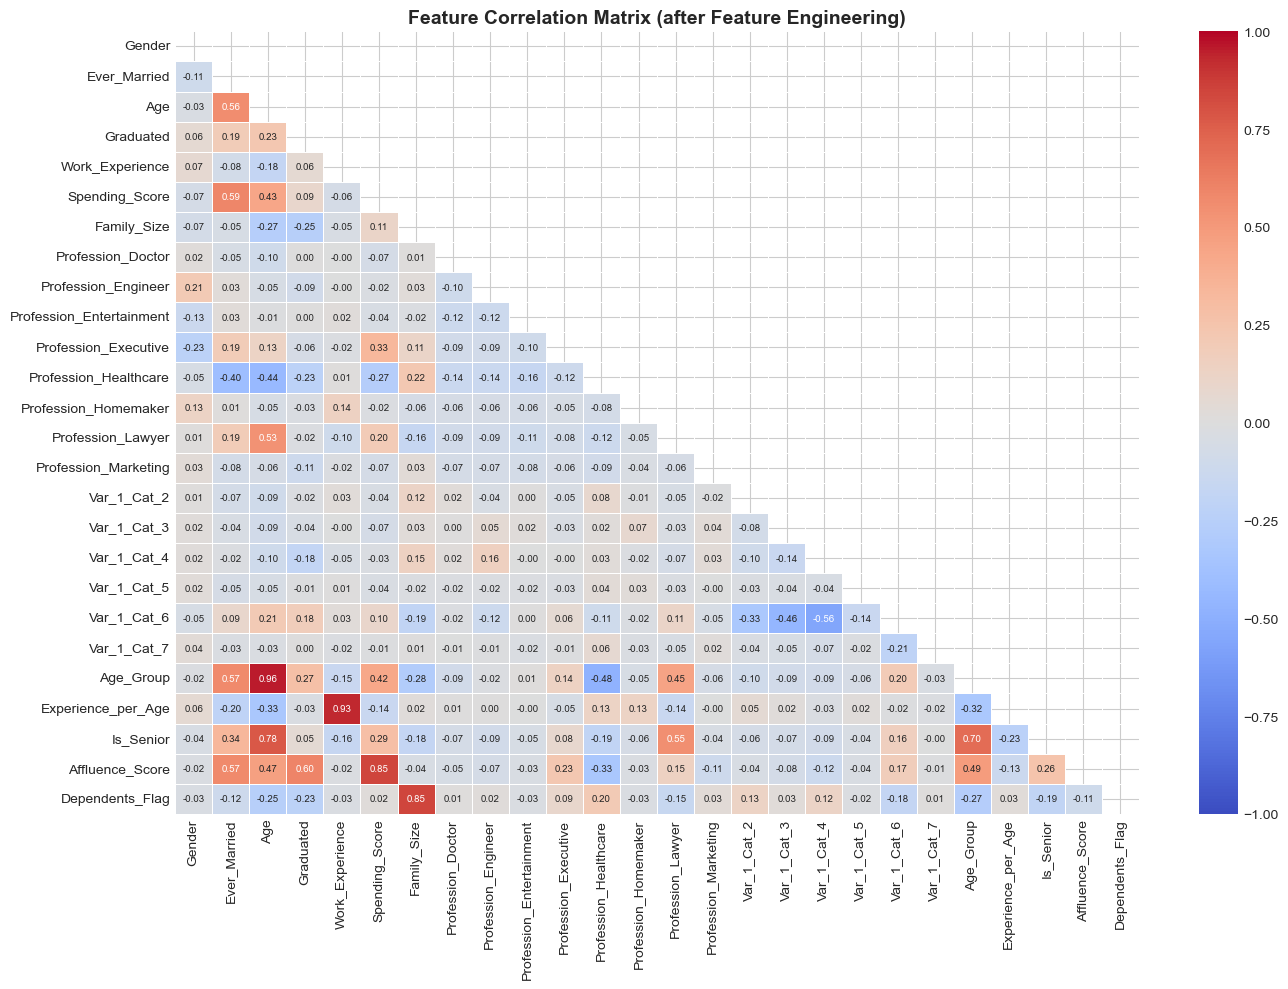

In [24]:
num_feats = df_fe.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df_fe[num_feats].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1, annot_kws={'size': 7})
plt.title('Feature Correlation Matrix (after Feature Engineering)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Data Transformation & Feature Scaling

Scaling is critical for distance-based clustering algorithms (K-Means, DBSCAN, etc.).  
We compare three scalers and apply **RobustScaler** (best for moderate outlier presence):


In [25]:
scale_cols = ['Age', 'Work_Experience', 'Family_Size',
              'Spending_Score', 'Experience_per_Age', 'Affluence_Score']

no_scale_cols = [c for c in df_fe.columns if c not in scale_cols]
print(f'Columns to scale     : {scale_cols}')
print(f'Columns kept as-is   : {no_scale_cols}')

Columns to scale     : ['Age', 'Work_Experience', 'Family_Size', 'Spending_Score', 'Experience_per_Age', 'Affluence_Score']
Columns kept as-is   : ['Gender', 'Ever_Married', 'Graduated', 'Profession_Doctor', 'Profession_Engineer', 'Profession_Entertainment', 'Profession_Executive', 'Profession_Healthcare', 'Profession_Homemaker', 'Profession_Lawyer', 'Profession_Marketing', 'Var_1_Cat_2', 'Var_1_Cat_3', 'Var_1_Cat_4', 'Var_1_Cat_5', 'Var_1_Cat_6', 'Var_1_Cat_7', 'Age_Group', 'Is_Senior', 'Dependents_Flag']


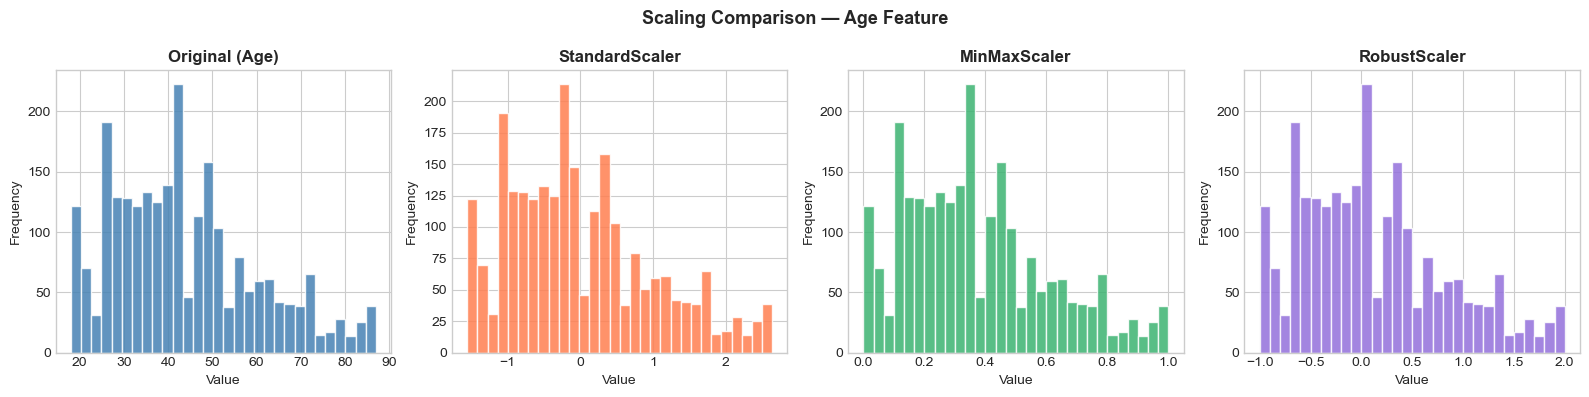

In [26]:
demo_col = 'Age'

std_vals    = StandardScaler().fit_transform(df_fe[[demo_col]])
minmax_vals = MinMaxScaler().fit_transform(df_fe[[demo_col]])
robust_vals = RobustScaler().fit_transform(df_fe[[demo_col]])

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
data_labels = [
    (df_fe[demo_col].values, 'Original (Age)', 'steelblue'),
    (std_vals.ravel(),       'StandardScaler', 'coral'),
    (minmax_vals.ravel(),    'MinMaxScaler',   'mediumseagreen'),
    (robust_vals.ravel(),    'RobustScaler',   'mediumpurple'),
]
for ax, (vals, title, color) in zip(axes, data_labels):
    ax.hist(vals, bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
plt.suptitle('Scaling Comparison — Age Feature', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
df_scaled = df_fe.copy()
scaler    = RobustScaler()

df_scaled[scale_cols] = scaler.fit_transform(df_fe[scale_cols])

print('Scaled feature statistics (should have near-zero median):')
display(df_scaled[scale_cols].describe().T[
    ['mean', 'std', 'min', '50%', 'max']
].rename(columns={'50%': 'median'}).round(4))

Scaled feature statistics (should have near-zero median):


,mean,std,min,median,max
Age,0.111,0.715,-1.000,0.000,2.000
Work_Experience,0.396,0.948,-0.333,0.000,3.000
Family_Size,0.375,0.703,-0.500,0.000,2.500
Spending_Score,0.535,0.732,0.000,0.000,2.000
Experience_per_Age,0.513,1.206,-0.325,0.000,6.146
Affluence_Score,0.080,0.457,-0.500,0.000,1.000


---
## 9. Train / Test Split

Although Customer Segmentation is an **unsupervised** task (clustering):
- Evaluating cluster stability on unseen data
- Validating that segment assignments generalise

In [28]:
train_df, test_df = train_test_split(df_scaled, test_size=0.2, random_state=42)

print(f'Training set : {train_df.shape[0]:,} rows  ({train_df.shape[0]/len(df_scaled)*100:.1f}%)')
print(f'Test set     : {test_df.shape[0]:,}  rows  ({test_df.shape[0]/len(df_scaled)*100:.1f}%)')
print(f'Features     : {df_scaled.shape[1]}')

Training set : 1,956 rows  (80.0%)
Test set     : 489  rows  (20.0%)
Features     : 26


---
## 10. Save Processed Datasets

In [29]:
df_scaled.to_csv('customer_segmentation_processed.csv', index=False)
train_df.to_csv('customer_seg_train.csv', index=False)
test_df.to_csv('customer_seg_test.csv', index=False)

print('Files saved:')
print('  customer_segmentation_processed.csv  — full processed dataset')
print('  customer_seg_train.csv               — 80% training split')
print('  customer_seg_test.csv                — 20% test split')

Files saved:
  customer_segmentation_processed.csv  — full processed dataset
  customer_seg_train.csv               — 80% training split
  customer_seg_test.csv                — 20% test split
